# EDA

## Table of Contents

## Set Up

In [2]:
# Standard imports
import numpy as np
import pandas as pd
import seaborn as sns
import matplotlib.pyplot as plt
import plotly.express as px
from plotly.subplots import make_subplots
import plotly.graph_objs as go

In [3]:
# show all dataframe columns
pd.set_option('display.max_columns', None)
# set matplotlib global settings eg. figsize
plt.rcParams['figure.figsize'] = (8.0, 6.0)

In [4]:
# Import hotel_clean_df
clean_df = pd.read_csv('clean_df')

#Import cxl_by_date
cxl_by_date = pd.read_csv('cxl_by_date')

#Import demand_by_date
demand_by_date = pd.read_csv('demand_by_date')

In [5]:
clean_df.head(5)
#cxl_by_date.head(5)
#demand_by_date.head(5)

,hotel,is_canceled,lead_time,arrival_date_week_number,stays_in_weekend_nights,stays_in_week_nights,adults,children,babies,meal,market_segment,distribution_channel,is_repeated_guest,previous_cancellations,previous_bookings_not_canceled,booking_changes,deposit_type,agent,company,days_in_waiting_list,customer_type,adr,required_car_parking_spaces,total_of_special_requests,reservation_status,reservation_status_date,arrival_date,day_demand
0,Resort Hotel,0,342,27,0,0,2,0,0,1,Direct,Direct,0,0,0,3,No Deposit,0,0,0,Transient,0.0,0,0,Check-Out,2015-07-01,2015-07-01,122
1,Resort Hotel,0,737,27,0,0,2,0,0,1,Direct,Direct,0,0,0,4,No Deposit,0,0,0,Transient,0.0,0,0,Check-Out,2015-07-01,2015-07-01,122
2,Resort Hotel,0,7,27,0,1,1,0,0,1,Direct,Direct,0,0,0,0,No Deposit,0,0,0,Transient,75.0,0,0,Check-Out,2015-07-02,2015-07-01,122
3,Resort Hotel,0,13,27,0,1,1,0,0,1,Corporate,Corporate,0,0,0,0,No Deposit,1,0,0,Transient,75.0,0,0,Check-Out,2015-07-02,2015-07-01,122
4,Resort Hotel,0,14,27,0,2,2,0,0,1,Online TA,TA/TO,0,0,0,0,No Deposit,1,0,0,Transient,98.0,0,1,Check-Out,2015-07-03,2015-07-01,122


# Additional EDA
- Total Cancellations
- Compare `market_segment` with `distribution_channel`. Are values the same? Can we drop one?
- Demand 
    - by `customer_type`
    - by `market_segment`/`distribution_channel`
- Cancellations
    - by `customer_type`
    - by `market_segment`/`distribution_channel`
- Booking Windows
    - Average `lead_time` of each reservation
    - `lead_time` by `customer_type`
    - `lead_time` by top 3 `market_segments`
- Cancellation Windows
    - How many days before arrival do cancellations occur? For `reservation_status` that are 'Canceled' how many days between `reservation_status_date` and `arrival_date`?
    - Cancellation window by `customer_type`
    - Cancellation window by `market_segment`


In [51]:
# Total Cancellations
total_reservations = clean_df.shape[0]
total_cancelled = clean_df['is_canceled'].value_counts()[1]
total_cancel_pct = clean_df['is_canceled'].value_counts(normalize=True)[1]

print(f'Total Reservations: {total_reservations}')
print(f"Total Canceled Reservations: {total_cancelled}")
print(f"Percentage of Reservations Cancelled: {np.round(total_cancel_pct,4)*100}%")

Total Reservations: 119390
Total Canceled Reservations: 44224
Percentage of Reservations Cancelled: 37.04%


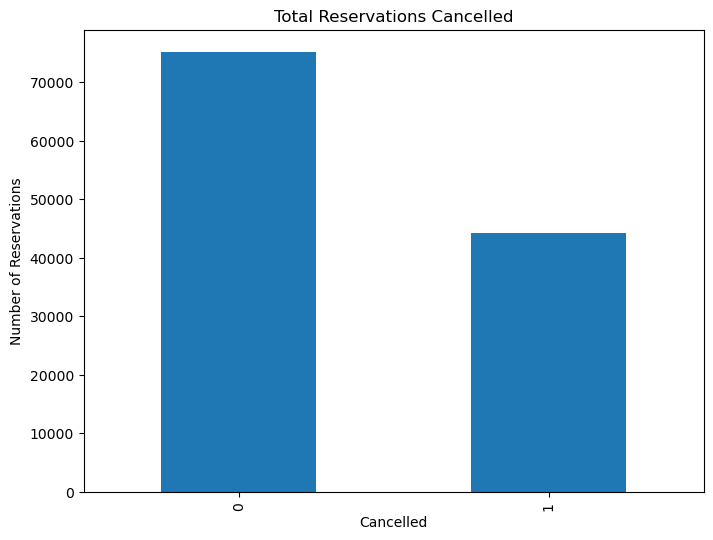

In [27]:
# Total Cancellations
clean_df['is_canceled'].value_counts().plot(kind='bar')

plt.title('Total Reservations Cancelled')
plt.xlabel('Cancelled')
plt.ylabel('Number of Reservations')
plt.show()


In [6]:
# Compare market_segment and distribution_channel
print(clean_df[['market_segment','distribution_channel']].value_counts(),'\n\n')
print(clean_df['market_segment'].value_counts(),'\n\n')
print(clean_df['distribution_channel'].value_counts())

market_segment  distribution_channel
Online TA       TA/TO                   56153
Offline TA/TO   TA/TO                   23946
Groups          TA/TO                   17111
Direct          Direct                  12276
Corporate       Corporate                4788
Groups          Direct                   1472
                Corporate                1228
Complementary   Direct                    576
Corporate       TA/TO                     335
Direct          TA/TO                     237
Aviation        Corporate                 227
Offline TA/TO   Corporate                 212
Corporate       Direct                    172
Online TA       GDS                       147
                Direct                    133
Direct          Corporate                  90
Complementary   Corporate                  89
                TA/TO                      78
Offline TA/TO   GDS                        45
Online TA       Corporate                  43
Offline TA/TO   Direct                     

The values "somewhat" overlap, however the market segment is the segmentation of the the guest type.  Whereas the distribution channel is the form in which the reservation was made.  These are indeed different and I will keep them separate.

In [ ]:
# Demand by customer_type
clean_df['customer_type'].value_counts(normalize=True) *100

customer_type
Transient          75.059050
Transient-Party    21.043638
Contract            3.414021
Group               0.483290
Name: proportion, dtype: float64

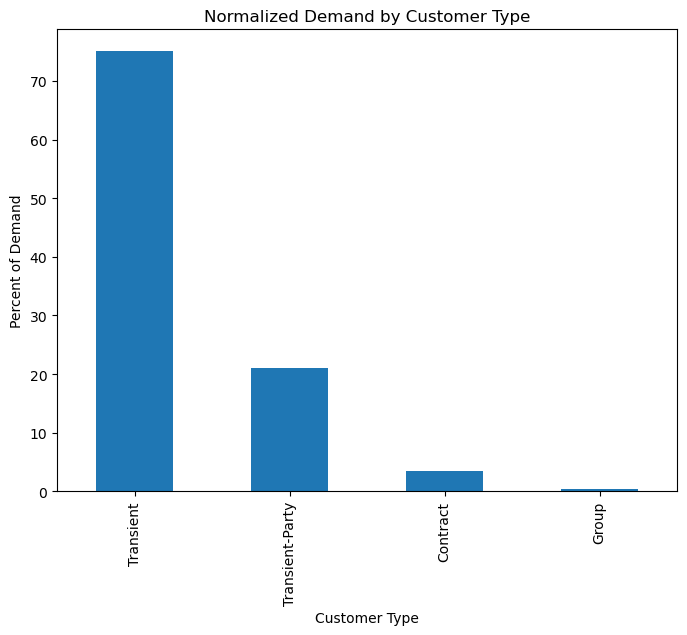

In [20]:
# Demand by customer_type
(clean_df['customer_type'].value_counts(normalize=True) * 100).plot(kind='bar')

plt.title('Normalized Demand by Customer Type')
plt.xlabel('Customer Type')
plt.ylabel('Percent of Demand')
plt.show()


`if i want to combine Transient + Transient-Party, do I do it here?`


In [21]:
# Demand by market_segment
clean_df['market_segment'].value_counts(normalize=True) *100

market_segment
Online TA        47.304632
Offline TA/TO    20.285619
Groups           16.593517
Direct           10.558673
Corporate         4.435045
Complementary     0.622330
Aviation          0.198509
Undefined         0.001675
Name: proportion, dtype: float64

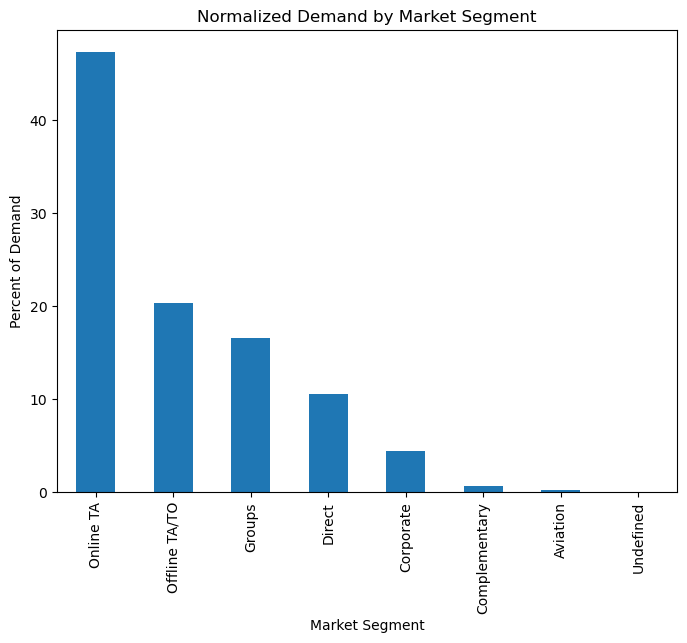

In [22]:
# Demand by market_segment
(clean_df['market_segment'].value_counts(normalize=True) * 100).plot(kind='bar')

plt.title('Normalized Demand by Market Segment')
plt.xlabel('Market Segment')
plt.ylabel('Percent of Demand')
plt.show()


<Axes: xlabel='is_canceled,customer_type'>

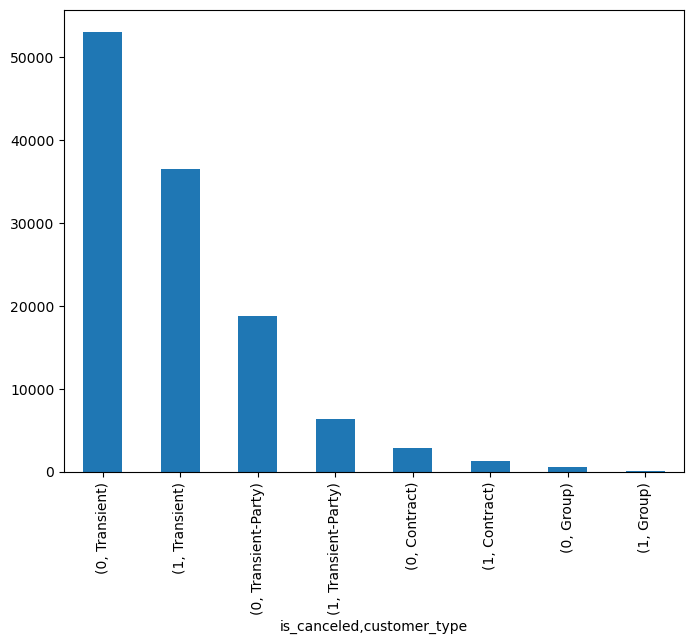

In [ ]:
# Cancellations by Customer Type
clean_df[['is_canceled','customer_type']].value_counts().plot(kind='bar')

plt.title('Cancellations by Customer Type')
plt.xlabel('Market Segment')
plt.ylabel('Percent of Demand')
plt.show()

In [ ]:
# Cancellations by Market Segment